# Clasificación Binaria de Tumores Mamarios



## Descenso de gradiente aplicado al Breast Cancer Wisconsin Dataset

## 1. Importación de librerías
Librerías necesarias y funciones creadas para cargar, preparar y probar el modelo base.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 2. Funciones de preparación del dataset


In [4]:
def descargar_cargar_datos():
    url = "https://raw.githubusercontent.com/selva86/datasets/master/BreastCancer.csv"
    df = pd.read_csv(url)

    df = df.drop(columns=['Id'], errors='ignore')
    df = df.dropna()

    valores_clase = df['Class'].unique()

    if not set(valores_clase).issubset({0, 1}):
        mapeo = {2: 0, 4: 1, '2': 0, '4': 1}
        df['Class'] = df['Class'].map(mapeo)

    df = df.dropna()
    return df

def normalizar_datos(df):
    y = df['Class'].values.reshape(-1, 1)
    X = df.drop(columns=['Class']).values

    x_min = X.min(axis=0)
    x_max = X.max(axis=0)

    X_normalizado = (X - x_min) / (x_max - x_min + 1e-8)
    return X_normalizado, y


def dividir_entrenamiento_prueba(X, y, porcentaje_entrenamiento=0.8):
    np.random.seed(42)
    indices = np.random.permutation(len(X))
    limite = int(len(X) * porcentaje_entrenamiento)

    indices_train = indices[:limite]
    indices_test = indices[limite:]

    X_train, X_test = X[indices_train], X[indices_test]
    y_train, y_test = y[indices_train], y[indices_test]

    return X_train, X_test, y_train, y_test

## 3. Modelo base

En esta sección se define la clase `NeuralNetwork`, que representa un modelo simple de clasificación binaria. El modelo calcula una combinación lineal de las variables de entrada y aplica una función sigmoide para obtener una probabilidad entre 0 y 1.

Esta parte corresponde al modelo base antes del entrenamiento.

In [5]:
class NeuralNetwork:
    def __init__(self, n_features):
        np.random.seed(42)

        self.W = np.random.rand(n_features, 1) * 0.01
        self.b = 0.0

    #se modifico esta funcion para que no de errores de overflow
    def sigmoid(self, z):
      resultado = np.empty_like(z, dtype=float)

      positivos = z >= 0
      negativos = ~positivos

      resultado[positivos] = 1 / (1 + np.exp(-z[positivos]))

      exp_z = np.exp(z[negativos])
      resultado[negativos] = exp_z / (1 + exp_z)

      return resultado

    def forward(self, X):
        z = np.dot(X, self.W) + self.b
        y_hat = self.sigmoid(z)

        return y_hat

## 4. Carga y verificación inicial del dataset

Se carga el dataset y se revisan sus dimensiones para confirmar que los datos fueron importados correctamente.

In [6]:
datos = descargar_cargar_datos()

print("Dataset completo:", datos.shape)
datos.head()

Dataset completo: (683, 10)


,Cl.thickness,Cell.size,Cell.shape,Marg.adhesion,Epith.c.size,Bare.nuclei,Bl.cromatin,Normal.nucleoli,Mitoses,Class
0,5,1,1,1,2,1.0,3,1,1,0
1,5,4,4,5,7,10.0,3,2,1,0
2,3,1,1,1,2,2.0,3,1,1,0
3,6,8,8,1,3,4.0,3,7,1,0
4,4,1,1,3,2,1.0,3,1,1,0


## 5. Preparación de los datos

En esta sección se separan las características de entrada `X` y la variable objetivo `y`.

También se normalizan las características usando Min-Max Scaling para que todas las variables queden en un rango comparable. Esto es importante porque el descenso de gradiente puede comportarse mal si las variables tienen escalas muy diferentes.

In [7]:
X, y = normalizar_datos(datos)

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)
print("Etiquetas encontradas en y:", set(y.flatten()))

Dimensiones de X: (683, 9)
Dimensiones de y: (683, 1)
Etiquetas encontradas en y: {np.int64(0), np.int64(1)}


La preparación de datos funcionó correctamente. El dataset quedó dividido en `X`, que contiene las 9 características utilizadas por el modelo, y `y`, que contiene la clase real de cada tumor.

La variable objetivo quedó codificada en formato binario, donde `0` representa tumor benigno y `1` representa tumor maligno.

## 6. División en entrenamiento y prueba

El dataset se divide en dos conjuntos:

- `train`: datos usados para entrenar el modelo.
- `test`: datos reservados para evaluar el desempeño final.

Se utiliza una semilla fija para que la división sea reproducible y el resultado sea el mismo cada vez que se ejecute el notebook.

In [8]:
X_train, X_test, y_train, y_test = dividir_entrenamiento_prueba(X, y)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (546, 9)
X_test: (137, 9)
y_train: (546, 1)
y_test: (137, 1)


La división de datos se realizó correctamente. El conjunto de entrenamiento quedó con 546 muestras y el conjunto de prueba con 137 muestras.

Cada muestra tiene 9 características, y cada etiqueta tiene una sola salida binaria. Esto confirma que los datos tienen dimensiones compatibles para alimentar el modelo de clasificación binaria.

## 7. Definición del modelo base

En esta sección se crea el modelo base de clasificación binaria.

La clase `NeuralNetwork` representa un modelo simple que recibe las características de entrada, calcula una combinación lineal y después aplica una función sigmoide para obtener una probabilidad entre 0 y 1.

En este punto el modelo todavía no está entrenado; solamente se verifica que pueda recibir los datos correctamente.

In [9]:
modelo = NeuralNetwork(n_features=X_train.shape[1])

print("Modelo creado correctamente.")
print("Número de características de entrada:", X_train.shape[1])
print("Dimensión de W:", modelo.W.shape)
print("Valor inicial de b:", modelo.b)

Modelo creado correctamente.
Número de características de entrada: 9
Dimensión de W: (9, 1)
Valor inicial de b: 0.0


## 8. Forward propagation inicial

Antes de entrenar el modelo, se realiza una primera propagación hacia adelante usando `X_train`.

El objetivo de esta prueba es comprobar que el modelo puede generar predicciones con dimensiones correctas. Como los pesos todavía no han sido ajustados mediante descenso de gradiente, se espera que las predicciones estén cerca de 0.5.

In [10]:
y_hat = modelo.forward(X_train)

print("Dimensiones de y_hat:", y_hat.shape)

print("\nPrimeras 5 predicciones:")
print(y_hat[:5])

print("\nRango de predicciones:")
print("mínimo:", y_hat.min())
print("máximo:", y_hat.max())

Dimensiones de y_hat: (546, 1)

Primeras 5 predicciones:
[[0.50418684]
 [0.50785804]
 [0.50007561]
 [0.50044523]
 [0.50001613]]

Rango de predicciones:
mínimo: 0.5
máximo: 0.5111345897654083


## 9. Función de costo: Log Loss / Binary Cross Entropy

In [11]:
def calcular_log_loss(y_real, y_pred):
    """
    Calcula la función de costo Log Loss / Binary Cross Entropy.

    y_real: etiquetas reales, valores 0 o 1
    y_pred: predicciones del modelo, valores entre 0 y 1
    """

    epsilon = 1e-15

    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)

    m = y_real.shape[0]

    costo = -np.sum(
        y_real * np.log(y_pred) + (1 - y_real) * np.log(1 - y_pred)
    ) / m

    return costo

costo_inicial = calcular_log_loss(y_train, y_hat)
print("Log Loss inicial:", costo_inicial)

Log Loss inicial: 0.6897930506300683


### Interpretación del costo inicial

El Log Loss inicial obtenido fue aproximadamente 0.69, lo cual es un resultado esperado antes del entrenamiento del modelo.

Esto ocurre porque los pesos todavía no han sido ajustados mediante descenso de gradiente, por lo que las predicciones iniciales del modelo se encuentran cerca de 0.5. En clasificación binaria, una predicción cercana a 0.5 indica que el modelo todavía no distingue claramente entre las dos clases.

Por lo tanto, este valor inicial sirve como punto de referencia. Durante el entrenamiento, el objetivo será actualizar los pesos y el sesgo para reducir progresivamente el Log Loss.

## 10. Entrenamiento del modelo: cálculo de gradientes

Antes de actualizar los pesos del modelo, primero se calcula el gradiente de la función de costo.

El gradiente indica en qué dirección deben modificarse los pesos para reducir el error del modelo.

Para el peso W, el gradiente se representa como dW.

### Calculo dW:

In [12]:
m = X_train.shape[0]

error = y_hat - y_train

dW = np.dot(X_train.T, error) / m

print("Dimensión de dW:", dW.shape)
print("Dimensión de W:", modelo.W.shape)

print("\nPrimeros 5 valores de dW:")
print(dW[:5])

Dimensión de dW: (9, 1)
Dimensión de W: (9, 1)

Primeros 5 valores de dW:
[[-0.04490377]
 [-0.0939208 ]
 [-0.08775628]
 [-0.07092046]
 [-0.03904881]]


### Calculo db:

In [13]:
db = np.sum(error) / m

print("Valor de db:", db)
print("Tipo de db:", type(db))

Valor de db: 0.15814200886231566
Tipo de db: <class 'numpy.float64'>


### Tasa de aprendizaje:

In [14]:
alpha = 0.01

print("Tasa de aprendizaje alpha:", alpha)

Tasa de aprendizaje alpha: 0.01


### Demostración manual de una actualización

En esta sección se realiza una sola actualización manual de los pesos W y del sesgo b para comprobar que el descenso de gradiente reduce el costo.

Esta parte es únicamente demostrativa. Antes del entrenamiento completo, el modelo se reinicia para que el entrenamiento final comience desde los pesos iniciales.

### Actualizar pesos W

In [15]:
W_anterior = modelo.W.copy()

modelo.W = modelo.W - alpha * dW

print("Dimensión de W anterior:", W_anterior.shape)
print("Dimensión de W actualizado:", modelo.W.shape)

print("\nPrimeros 5 valores de W antes:")
print(W_anterior[:5])

print("\nPrimeros 5 valores de W después:")
print(modelo.W[:5])

Dimensión de W anterior: (9, 1)
Dimensión de W actualizado: (9, 1)

Primeros 5 valores de W antes:
[[0.0037454 ]
 [0.00950714]
 [0.00731994]
 [0.00598658]
 [0.00156019]]

Primeros 5 valores de W después:
[[0.00419444]
 [0.01044635]
 [0.0081975 ]
 [0.00669579]
 [0.00195067]]


### Actualizar sesgo b

In [16]:
b_anterior = modelo.b

modelo.b = modelo.b - alpha * db

print("b anterior:", b_anterior)
print("b actualizado:", modelo.b)

b anterior: 0.0
b actualizado: -0.0015814200886231566


### Prueba de verificacion para comprobar si logramos redujir el costo

In [17]:
y_hat_actualizado = modelo.forward(X_train)

costo_despues_actualizacion = calcular_log_loss(y_train, y_hat_actualizado)

print("Costo inicial:", costo_inicial)
print("Costo después de una actualización:", costo_despues_actualizacion)
print("Reducción del costo:", costo_inicial - costo_despues_actualizacion)

Costo inicial: 0.6897930506300683
Costo después de una actualización: 0.6890476995702326
Reducción del costo: 0.0007453510598357527


## 11. Bucle de entrenamiento por épocas

Para entrenar el modelo de forma completa, se repetirá varias veces el proceso de forward propagation, cálculo de costo, cálculo de gradientes y actualización de parámetros.

Cada repetición del proceso se conoce como época.

Antes de crear el bucle, se reinicia el modelo para que el entrenamiento comience desde los pesos iniciales y no desde la actualización manual realizada previamente.

In [18]:
modelo = NeuralNetwork(n_features=X_train.shape[1])

y_hat = modelo.forward(X_train)

costo_reiniciado = calcular_log_loss(y_train, y_hat)

print("Dimensión de W reiniciado:", modelo.W.shape)
print("b reiniciado:", modelo.b)
print("Costo después de reiniciar el modelo:", costo_reiniciado)

Dimensión de W reiniciado: (9, 1)
b reiniciado: 0.0
Costo después de reiniciar el modelo: 0.6897930506300683


### Crear el bucle de entrenamiento:

Vamos a hacer un bucle pequeño, de solo 5 épocas, para comprobar que funciona. Todavía no haremos el entrenamiento grande.

Qué hará cada época

Cada vuelta del bucle hará esto:

1. Calcular predicciones: y_hat
2. Calcular costo
3. Calcular error
4. Calcular dW
5. Calcular db
6. Actualizar W
7. Actualizar b

In [19]:
epocas = 5
alpha = 0.01

for epoca in range(epocas):
    y_hat = modelo.forward(X_train)

    costo = calcular_log_loss(y_train, y_hat)

    error = y_hat - y_train

    m = X_train.shape[0]

    dW = np.dot(X_train.T, error) / m
    db = np.sum(error) / m

    modelo.W = modelo.W - alpha * dW
    modelo.b = modelo.b - alpha * db

    print("Época:", epoca + 1, "| Costo:", costo)

Época: 1 | Costo: 0.6897930506300683
Época: 2 | Costo: 0.6890476995702326
Época: 3 | Costo: 0.688303826801902
Época: 4 | Costo: 0.6875614280881319
Época: 5 | Costo: 0.6868204992095849


### Historial de pérdida

Durante el entrenamiento, se guardará el valor del costo en cada época dentro de una lista llamada historial_perdida.

Esto permite analizar si el error del modelo disminuye progresivamente conforme avanza el entrenamiento.

In [20]:
modelo = NeuralNetwork(n_features=X_train.shape[1])

epocas = 5
alpha = 0.01

historial_perdida = []

for epoca in range(epocas):
    y_hat = modelo.forward(X_train)

    costo = calcular_log_loss(y_train, y_hat)

    historial_perdida.append(float(costo))

    error = y_hat - y_train

    m = X_train.shape[0]

    dW = np.dot(X_train.T, error) / m
    db = np.sum(error) / m

    modelo.W = modelo.W - alpha * dW
    modelo.b = modelo.b - alpha * db

    print("Época:", epoca + 1, "| Costo:", costo)

print("\nHistorial de pérdida:")
print(historial_perdida)

Época: 1 | Costo: 0.6897930506300683
Época: 2 | Costo: 0.6890476995702326
Época: 3 | Costo: 0.688303826801902
Época: 4 | Costo: 0.6875614280881319
Época: 5 | Costo: 0.6868204992095849

Historial de pérdida:
[0.6897930506300683, 0.6890476995702326, 0.688303826801902, 0.6875614280881319, 0.6868204992095849]


### Verifica que la perdida disminuya:

In [21]:
perdida_disminuye = True

for i in range(len(historial_perdida) - 1):
    if historial_perdida[i + 1] >= historial_perdida[i]:
        perdida_disminuye = False

print("Costo inicial:", historial_perdida[0])
print("Costo final:", historial_perdida[-1])
print("Reducción total:", historial_perdida[0] - historial_perdida[-1])
print("¿La pérdida disminuyó en todas las épocas?:", perdida_disminuye)

Costo inicial: 0.6897930506300683
Costo final: 0.6868204992095849
Reducción total: 0.0029725514204834713
¿La pérdida disminuyó en todas las épocas?: True


## 12. Entrenamiento completo del modelo

Después de verificar que el costo disminuye correctamente en pocas épocas, se realiza un entrenamiento completo usando X_train y y_train.

En esta etapa se aumenta el número de épocas para permitir que el modelo ajuste mejor sus pesos y sesgo mediante descenso de gradiente.

In [22]:
modelo = NeuralNetwork(n_features=X_train.shape[1])

epocas = 1000
alpha = 0.01

historial_perdida = []

for epoca in range(epocas):
    y_hat = modelo.forward(X_train)

    costo = calcular_log_loss(y_train, y_hat)
    historial_perdida.append(float(costo))

    error = y_hat - y_train

    m = X_train.shape[0]

    dW = np.dot(X_train.T, error) / m
    db = np.sum(error) / m

    modelo.W = modelo.W - alpha * dW
    modelo.b = modelo.b - alpha * db

    if (epoca + 1) % 100 == 0:
        print("Época:", epoca + 1, "| Costo:", round(float(costo), 6))

print("\nEntrenamiento completo finalizado.")
print("Costo inicial:", historial_perdida[0])
print("Costo final:", historial_perdida[-1])
print("Reducción total:", historial_perdida[0] - historial_perdida[-1])

Época: 100 | Costo: 0.622571
Época: 200 | Costo: 0.566048
Época: 300 | Costo: 0.518521
Época: 400 | Costo: 0.478211
Época: 500 | Costo: 0.443757
Época: 600 | Costo: 0.414097
Época: 700 | Costo: 0.388385
Época: 800 | Costo: 0.365946
Época: 900 | Costo: 0.34624
Época: 1000 | Costo: 0.328829

Entrenamiento completo finalizado.
Costo inicial: 0.6897930506300683
Costo final: 0.3288287136072024
Reducción total: 0.36096433702286596


### Verificación de dimensiones después del entrenamiento

In [23]:
y_hat_train = modelo.forward(X_train)

print("Dimensión de X_train:", X_train.shape)
print("Dimensión de y_train:", y_train.shape)
print("Dimensión de W:", modelo.W.shape)
print("Valor de b:", modelo.b)
print("Dimensión de y_hat_train:", y_hat_train.shape)

print("\nRango de predicciones:")
print("Mínimo:", y_hat_train.min())
print("Máximo:", y_hat_train.max())

Dimensión de X_train: (546, 9)
Dimensión de y_train: (546, 1)
Dimensión de W: (9, 1)
Valor de b: -1.2230631167406594
Dimensión de y_hat_train: (546, 1)

Rango de predicciones:
Mínimo: 0.22739784819613357
Máximo: 0.9253817815188532


### Verificación de estabilidad de la pérdida

In [24]:
perdida_disminuye_estable = True

for i in range(len(historial_perdida) - 1):
    if historial_perdida[i + 1] > historial_perdida[i]:
        perdida_disminuye_estable = False

costos_finitos = np.all(np.isfinite(historial_perdida))

print("Costo inicial:", historial_perdida[0])
print("Costo final:", historial_perdida[-1])
print("Reducción total:", historial_perdida[0] - historial_perdida[-1])
print("¿La pérdida disminuyó de forma estable?:", perdida_disminuye_estable)
print("¿Todos los costos son finitos?:", costos_finitos)

Costo inicial: 0.6897930506300683
Costo final: 0.3288287136072024
Reducción total: 0.36096433702286596
¿La pérdida disminuyó de forma estable?: True
¿Todos los costos son finitos?: True


### Revisión de la tasa de aprendizaje

El entrenamiento se mantuvo estable usando una tasa de aprendizaje alpha = 0.01.

La pérdida disminuyó progresivamente desde 0.6897 hasta 0.3288 y todos los valores de costo fueron finitos. Por lo tanto, no fue necesario modificar la tasa de aprendizaje.

### Confirmación del modelo entrenado para métricas

In [25]:
y_hat_test = modelo.forward(X_test)

y_pred_test = (y_hat_test >= 0.5).astype(int)

print("Dimensión de X_test:", X_test.shape)
print("Dimensión de y_test:", y_test.shape)
print("Dimensión de y_hat_test:", y_hat_test.shape)
print("Dimensión de y_pred_test:", y_pred_test.shape)

print("\nRango de probabilidades en test:")
print("Mínimo:", y_hat_test.min())
print("Máximo:", y_hat_test.max())

print("\nPrimeras 10 probabilidades:")
print(y_hat_test[:10].flatten())

print("\nPrimeras 10 predicciones binarias:")
print(y_pred_test[:10].flatten())

Dimensión de X_test: (137, 9)
Dimensión de y_test: (137, 1)
Dimensión de y_hat_test: (137, 1)
Dimensión de y_pred_test: (137, 1)

Rango de probabilidades en test:
Mínimo: 0.22739784819613357
Máximo: 0.9041344060467782

Primeras 10 probabilidades:
[0.24860147 0.25542796 0.26152393 0.77215297 0.25542796 0.2916165
 0.26748304 0.8056719  0.39346805 0.25113445]

Primeras 10 predicciones binarias:
[0 0 0 1 0 0 0 1 0 0]


## 13. Resultados y visualización

### Predicciones finales del modelo

Después de entrenar el modelo, se generan predicciones sobre el conjunto de prueba X_test.

Primero se obtienen probabilidades usando la función sigmoide. Después, esas probabilidades se convierten a clases binarias usando un umbral de 0.5.

In [26]:
y_hat_test = modelo.forward(X_test)

y_pred_test = (y_hat_test >= 0.5).astype(int)

print("Dimensión de y_hat_test:", y_hat_test.shape)
print("Dimensión de y_pred_test:", y_pred_test.shape)

print("\nPrimeras 10 probabilidades:")
print(y_hat_test[:10].flatten())

print("\nPrimeras 10 clases predichas:")
print(y_pred_test[:10].flatten())

Dimensión de y_hat_test: (137, 1)
Dimensión de y_pred_test: (137, 1)

Primeras 10 probabilidades:
[0.24860147 0.25542796 0.26152393 0.77215297 0.25542796 0.2916165
 0.26748304 0.8056719  0.39346805 0.25113445]

Primeras 10 clases predichas:
[0 0 0 1 0 0 0 1 0 0]


### Cálculo de accuracy

El accuracy mide la proporción de predicciones correctas realizadas por el modelo sobre el conjunto de prueba.

Se calcula comparando las clases predichas `y_pred_test` contra las etiquetas reales `y_test`.

In [27]:
accuracy = np.mean(y_pred_test == y_test)

print("Accuracy:", accuracy)
print("Accuracy en porcentaje:", round(accuracy * 100, 2), "%")

Accuracy: 0.9635036496350365
Accuracy en porcentaje: 96.35 %


### Cálculo de precisión

La precisión mide qué tan confiables son las predicciones positivas del modelo.

En este caso, se calcula cuántas de las predicciones clasificadas como clase 1 realmente pertenecen a la clase 1.

In [28]:
TP = np.sum((y_pred_test == 1) & (y_test == 1))
FP = np.sum((y_pred_test == 1) & (y_test == 0))

precision = TP / (TP + FP)

print("Verdaderos positivos TP:", TP)
print("Falsos positivos FP:", FP)
print("Precisión:", precision)
print("Precisión en porcentaje:", round(precision * 100, 2), "%")

Verdaderos positivos TP: 48
Falsos positivos FP: 2
Precisión: 0.96
Precisión en porcentaje: 96.0 %


### Cálculo de recall

El recall mide qué proporción de los casos reales de la clase 1 fueron detectados correctamente por el modelo.

Se calcula usando los verdaderos positivos y los falsos negativos.

In [29]:
FN = np.sum((y_pred_test == 0) & (y_test == 1))

recall = TP / (TP + FN)

print("Verdaderos positivos TP:", TP)
print("Falsos negativos FN:", FN)
print("Recall:", recall)
print("Recall en porcentaje:", round(recall * 100, 2), "%")

Verdaderos positivos TP: 48
Falsos negativos FN: 3
Recall: 0.9411764705882353
Recall en porcentaje: 94.12 %


### Cálculo de F1-score

El F1-score combina la precisión y el recall en una sola métrica.

Esta métrica es útil porque resume el equilibrio entre la capacidad del modelo para hacer predicciones positivas correctas y su capacidad para detectar los casos positivos reales.

In [30]:
f1_score = 2 * (precision * recall) / (precision + recall)

print("Precisión:", precision)
print("Recall:", recall)
print("F1-score:", f1_score)
print("F1-score en porcentaje:", round(f1_score * 100, 2), "%")

Precisión: 0.96
Recall: 0.9411764705882353
F1-score: 0.9504950495049505
F1-score en porcentaje: 95.05 %


### Matriz de confusión

La matriz de confusión permite observar cuántas predicciones fueron correctas e incorrectas para cada clase.

En clasificación binaria se compone de verdaderos negativos, falsos positivos, falsos negativos y verdaderos positivos.

In [31]:
TN = np.sum((y_pred_test == 0) & (y_test == 0))
FP = np.sum((y_pred_test == 1) & (y_test == 0))
FN = np.sum((y_pred_test == 0) & (y_test == 1))
TP = np.sum((y_pred_test == 1) & (y_test == 1))

matriz_confusion = np.array([
    [TN, FP],
    [FN, TP]
])

print("Matriz de confusión:")
print(matriz_confusion)

print("\nVerdaderos negativos TN:", TN)
print("Falsos positivos FP:", FP)
print("Falsos negativos FN:", FN)
print("Verdaderos positivos TP:", TP)

Matriz de confusión:
[[84  2]
 [ 3 48]]

Verdaderos negativos TN: 84
Falsos positivos FP: 2
Falsos negativos FN: 3
Verdaderos positivos TP: 48


### Gráfica de la matriz de confusión

Para visualizar mejor los resultados del modelo, se representa la matriz de confusión mediante una gráfica.

Esta visualización permite identificar rápidamente la cantidad de verdaderos negativos, falsos positivos, falsos negativos y verdaderos positivos.

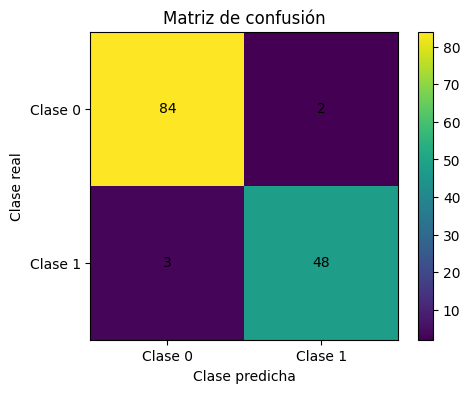

In [32]:
fig, ax = plt.subplots(figsize=(5, 4))

imagen = ax.imshow(matriz_confusion)

ax.set_title("Matriz de confusión")
ax.set_xlabel("Clase predicha")
ax.set_ylabel("Clase real")

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

ax.set_xticklabels(["Clase 0", "Clase 1"])
ax.set_yticklabels(["Clase 0", "Clase 1"])

for i in range(2):
    for j in range(2):
        ax.text(j, i, matriz_confusion[i, j],
                ha="center", va="center")

plt.colorbar(imagen)
plt.show()

### Curva de pérdida durante el entrenamiento

La curva de pérdida muestra cómo cambia el valor del Log Loss conforme avanzan las épocas de entrenamiento.

Si el descenso de gradiente funciona correctamente, se espera que la pérdida disminuya progresivamente.

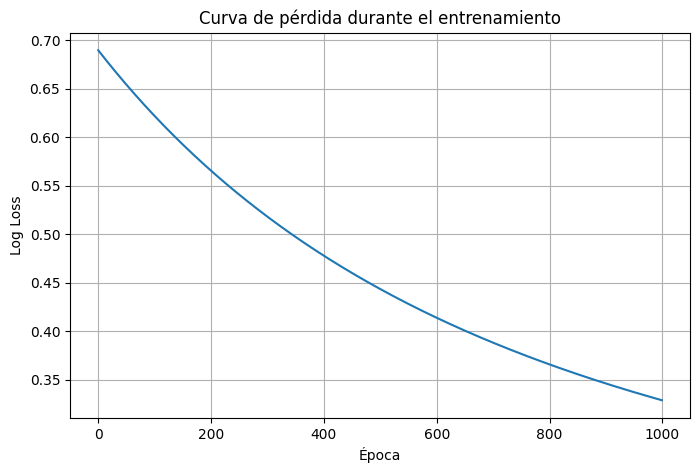

In [33]:
plt.figure(figsize=(8, 5))

plt.plot(historial_perdida)

plt.title("Curva de pérdida durante el entrenamiento")
plt.xlabel("Época")
plt.ylabel("Log Loss")

plt.grid(True)
plt.show()

### Resumen final de métricas del modelo

In [35]:
from IPython.display import display

resumen_metricas = pd.DataFrame({
    "Métrica": ["Accuracy", "Precisión", "Recall", "F1-score"],
    "Valor decimal": [accuracy, precision, recall, f1_score],
    "Porcentaje": [accuracy * 100, precision * 100, recall * 100, f1_score * 100]
})

tabla_metricas = resumen_metricas.style.format({
    "Valor decimal": "{:.4f}",
    "Porcentaje": "{:.2f} %"
}).set_caption("Resumen final de métricas del modelo").hide(axis="index")

display(tabla_metricas)

matriz_confusion_df = pd.DataFrame(
    matriz_confusion,
    index=["Clase real 0", "Clase real 1"],
    columns=["Predicción 0", "Predicción 1"]
)

tabla_matriz = matriz_confusion_df.style.set_caption("Matriz de confusión")

display(tabla_matriz)

Métrica,Valor decimal,Porcentaje
Accuracy,0.9635,96.35 %
Precisión,0.9600,96.00 %
Recall,0.9412,94.12 %
F1-score,0.9505,95.05 %


,Predicción 0,Predicción 1
Clase real 0,84,2
Clase real 1,3,48
